In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv()

conn = psycopg2.connect(
    host=os.getenv("POSTGRES_HOST", "localhost"),
    port=int(os.getenv("POSTGRES_PORT", 5432)),
    dbname=os.getenv("POSTGRES_DB", "nba2k_db"),
    user=os.getenv("POSTGRES_USER", "nba2k_user"),
    password=os.getenv("POSTGRES_PASSWORD", "nba2k_pass"),
)

df = pd.read_sql("SELECT * FROM ml_dataset ORDER BY player_name, season_year", conn)
print(df.shape)
df.head()

(4442, 31)


C:\Users\migue\AppData\Local\Temp\ipykernel_18744\2173867425.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM ml_dataset ORDER BY player_name, season_year", conn)


,player_id,player_name,season,game_version,season_year,ovr_rating,is_rookie,age,gp,min,...,ast_pct,ast_to,pie,career_year,pts_delta,reb_delta,ast_delta,ovr_prev,ovr_delta,split
0,203932,Aaron Gordon,2018-19,nba-2k20,2019,81.0,False,23.0,78,33.8,...,0.166,1.78,0.109,None,None,None,None,None,None,train
1,203932,Aaron Gordon,2019-20,nba-2k21,2020,80.0,False,24.0,62,32.5,...,0.165,2.28,0.104,None,None,None,None,None,None,train
2,203932,Aaron Gordon,2020-21,nba-2k22,2021,78.0,False,25.0,50,27.7,...,0.165,1.66,0.095,None,None,None,None,None,None,train
3,203932,Aaron Gordon,2021-22,nba-2k23,2022,79.0,False,26.0,75,31.7,...,0.109,1.41,0.096,None,None,None,None,None,None,train
4,203932,Aaron Gordon,2022-23,nba-2k24,2023,84.0,False,27.0,68,30.2,...,0.129,2.07,0.112,None,None,None,None,None,None,train


### Basic Info

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4442 entries, 0 to 4441
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   player_id     4442 non-null   int64  
 1   player_name   4442 non-null   object 
 2   season        4442 non-null   object 
 3   game_version  4442 non-null   object 
 4   season_year   4442 non-null   int64  
 5   ovr_rating    2916 non-null   float64
 6   is_rookie     4442 non-null   bool   
 7   age           4442 non-null   float64
 8   gp            4442 non-null   int64  
 9   min           4442 non-null   float64
 10  pts           4442 non-null   float64
 11  reb           4442 non-null   float64
 12  ast           4442 non-null   float64
 13  stl           4442 non-null   float64
 14  blk           4442 non-null   float64
 15  tov           4442 non-null   float64
 16  fg_pct        4442 non-null   float64
 17  fg3_pct       4442 non-null   float64
 18  ft_pct        4442 non-null 

### Check nulls

In [3]:
df.isnull().sum().sort_values(ascending=False)

ovr_delta       4442
ovr_prev        4442
ast_delta       4442
reb_delta       4442
pts_delta       4442
career_year     4442
ovr_rating      1526
player_id          0
fg_pct             0
pie                0
ast_to             0
ast_pct            0
usg_pct            0
net_rating         0
ft_pct             0
fg3_pct            0
tov                0
player_name        0
blk                0
stl                0
ast                0
reb                0
pts                0
min                0
gp                 0
age                0
is_rookie          0
season_year        0
game_version       0
season             0
split              0
dtype: int64

- ovr_delta, ovr_prev, pts_delta etc. = 4,442 nulls — these are the features table columns we haven't populated yet, that's expected
- ovr_rating = 1,526 nulls — these are the predict rows (558) plus rookies with no stats

### Rating Distribution

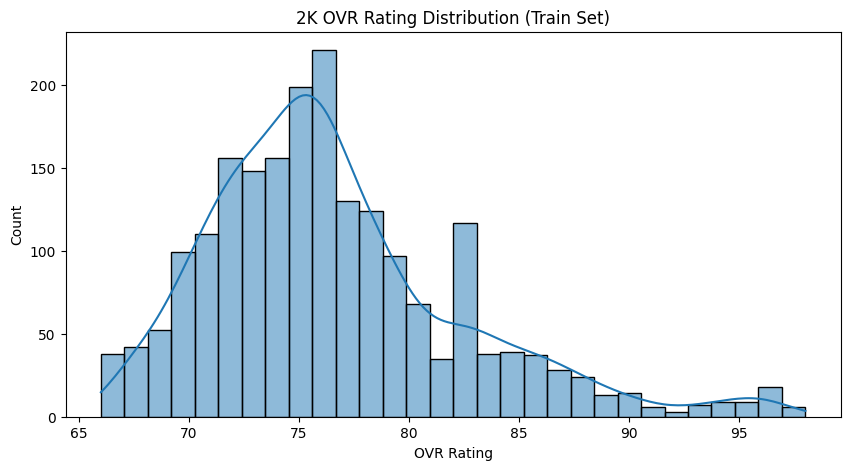

In [4]:
train = df[df["split"] == "train"]

plt.figure(figsize=(10, 5))
sns.histplot(train["ovr_rating"].dropna(), bins=30, kde=True)
plt.title("2K OVR Rating Distribution (Train Set)")
plt.xlabel("OVR Rating")
plt.ylabel("Count")
plt.show()

- Most players cluster between 70-80 OVR — that's the typical rotation player range
- The bump around 82-83 is interesting — likely starter-level players
- The long right tail is the superstars (90+)
- This is a right-skewed distribution which is expected



### Correlation Heatmap

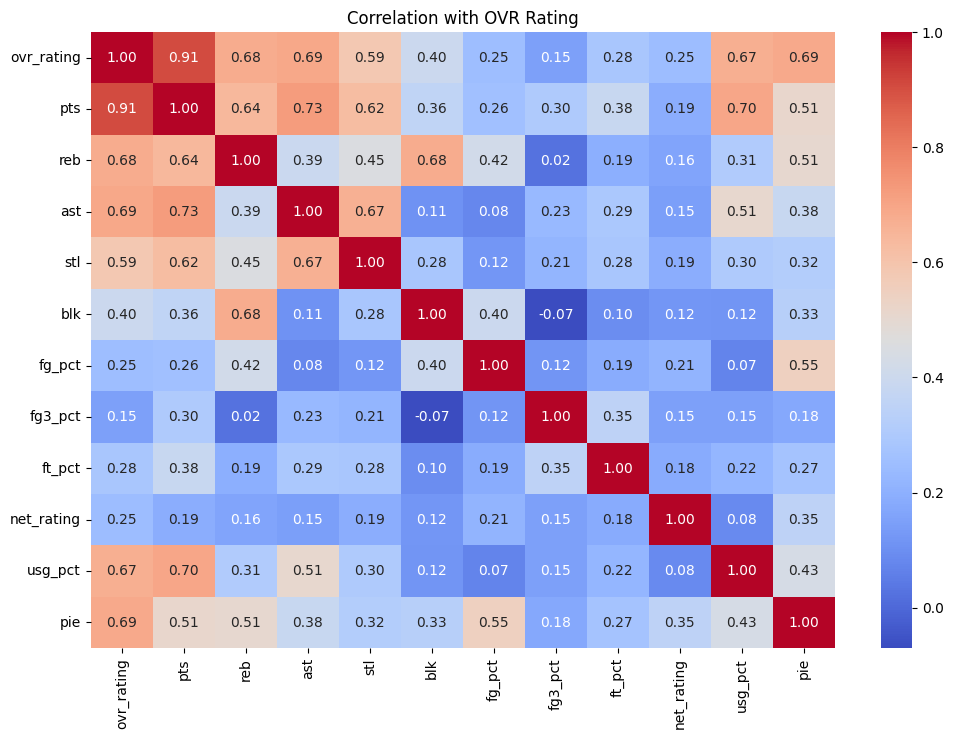

In [5]:
stat_cols = ["ovr_rating", "pts", "reb", "ast", "stl", "blk",
             "fg_pct", "fg3_pct", "ft_pct", "net_rating", "usg_pct", "pie"]

plt.figure(figsize=(12, 8))
sns.heatmap(train[stat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation with OVR Rating")
plt.show()

- pts = 0.91 — by far the strongest predictor. 2K heavily weights scoring
- pie = 0.69 — Player Impact Estimate is a strong signal
- usg_pct = 0.67 — usage rate matters, high usage = higher rated
- ast = 0.69 — assists are important
- reb = 0.68 — rebounds matter too
- net_rating = 0.25 — surprisingly weak, 2K doesn't care much about team impact
- fg3_pct = 0.15 — three point percentage barely matters
- blk = 0.40 — blocks have moderate influence

In [6]:
# Top stats by correlation with OVR rating
corr = train[stat_cols].corr()["ovr_rating"].sort_values(ascending=False)
print(corr)

ovr_rating    1.000000
pts           0.906383
ast           0.694608
pie           0.688986
reb           0.678496
usg_pct       0.671799
stl           0.585496
blk           0.397752
ft_pct        0.282627
fg_pct        0.251594
net_rating    0.247224
fg3_pct       0.150515
Name: ovr_rating, dtype: float64


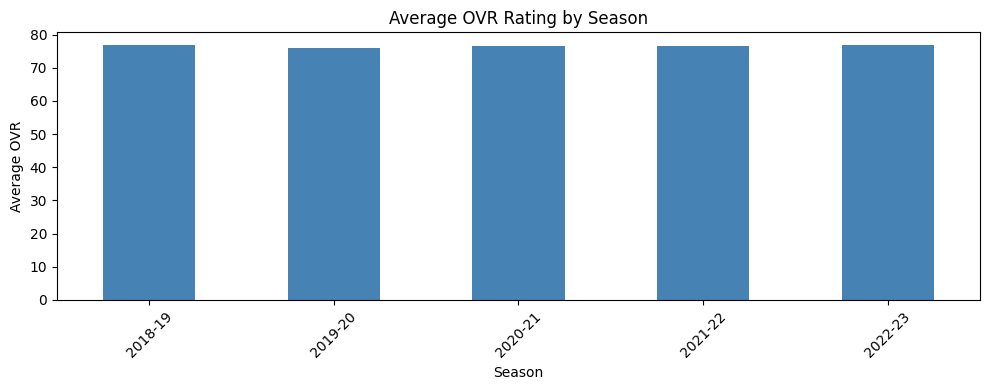

season
2018-19    76.859551
2019-20    76.105882
2020-21    76.699005
2021-22    76.471292
2022-23    76.776018
Name: ovr_rating, dtype: float64


In [7]:
# Average OVR rating per season — has 2K been inflating ratings over time?
season_avg = train.groupby("season")["ovr_rating"].mean().sort_index()
plt.figure(figsize=(10, 4))
season_avg.plot(kind="bar", color="steelblue")
plt.title("Average OVR Rating by Season")
plt.xlabel("Season")
plt.ylabel("Average OVR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(season_avg)

In [8]:
# Top 10 highest rated players in training set
print("Top 10 highest rated:")
print(train.nlargest(10, "ovr_rating")[["player_name", "season", "ovr_rating", "pts", "reb", "ast"]].to_string(index=False))

print("\nBottom 10 lowest rated:")
print(train.nsmallest(10, "ovr_rating")[["player_name", "season", "ovr_rating", "pts", "reb", "ast"]].to_string(index=False))

print("\nMost improved (biggest OVR jump year over year):")
print(train.nlargest(10, "pts")[["player_name", "season", "ovr_rating", "pts", "usg_pct"]].to_string(index=False))

Top 10 highest rated:
          player_name  season  ovr_rating  pts  reb  ast
         Nikola Jokić 2022-23        98.0 24.5 11.8  9.8
Giannis Antetokounmpo 2019-20        97.0 29.5 13.6  5.6
Giannis Antetokounmpo 2021-22        97.0 29.9 11.6  5.8
        Kawhi Leonard 2018-19        97.0 26.6  7.3  3.3
         LeBron James 2018-19        97.0 27.4  8.5  8.3
         LeBron James 2019-20        97.0 25.3  7.8 10.2
Giannis Antetokounmpo 2018-19        96.0 27.7 12.5  5.9
Giannis Antetokounmpo 2020-21        96.0 28.1 11.0  5.9
Giannis Antetokounmpo 2022-23        96.0 31.1 11.8  5.7
         James Harden 2018-19        96.0 36.1  6.6  7.5

Bottom 10 lowest rated:
     player_name  season  ovr_rating  pts  reb  ast
       PJ Dozier 2018-19        66.0  3.2  2.8  0.8
     A.J. Lawson 2022-23        67.0  3.7  1.4  0.1
Alondes Williams 2022-23        67.0  0.0  1.0  0.0
     Braxton Key 2021-22        67.0  7.2  4.5  1.0
     Braxton Key 2022-23        67.0  1.3  0.3  0.0
    Carlik Jon